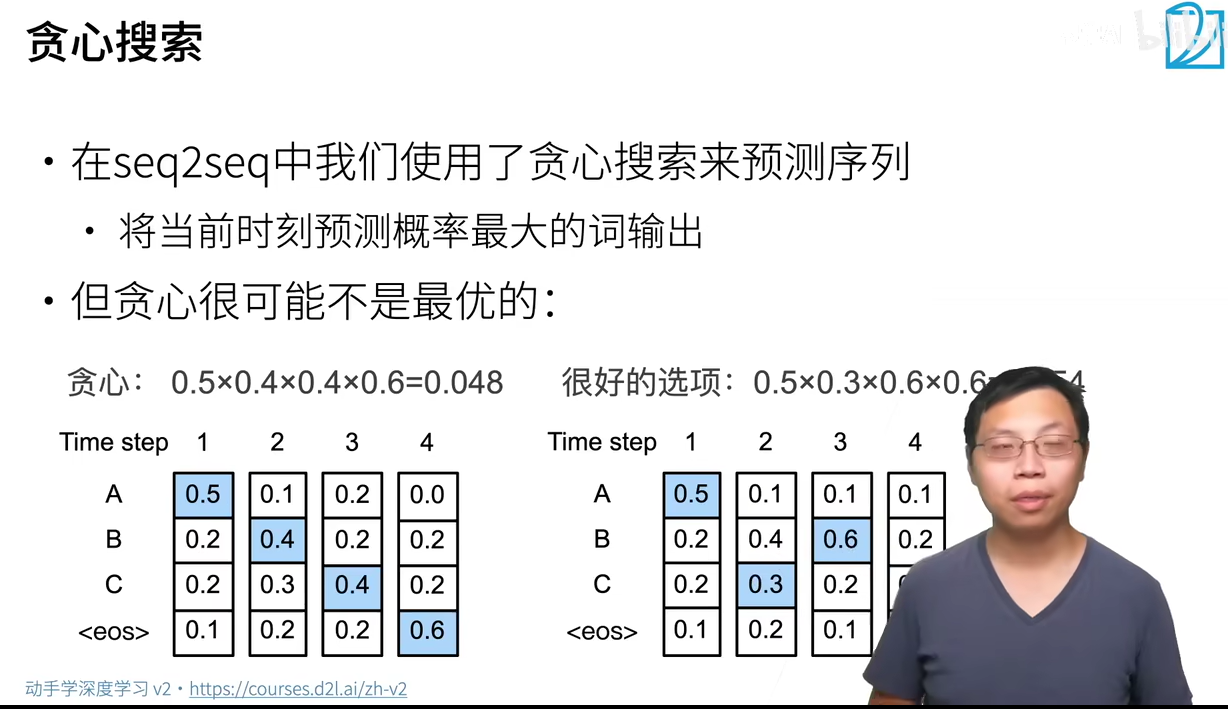
在钱一个状态对后一个状态有影响的前提下：局部最优！=全局最优

局部最优：每次选择一个分支，对于序列长度为n,实时间步长度为t的时间复杂度为 O(t).

全局最优：只能枚举每一种状态，对于序列长度为n,实时间步长度为t的时间复杂度为O(n**t)

为了权衡时间复杂度与搜素效果引入束搜索
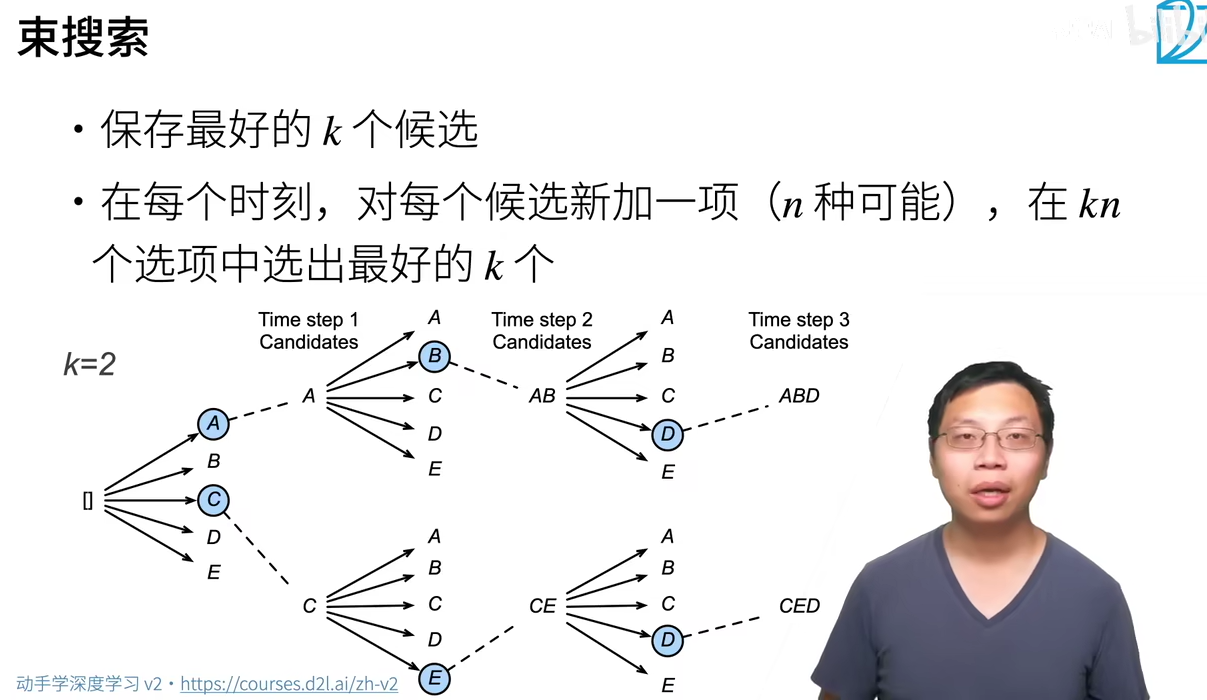
时间复杂度为O(knt)

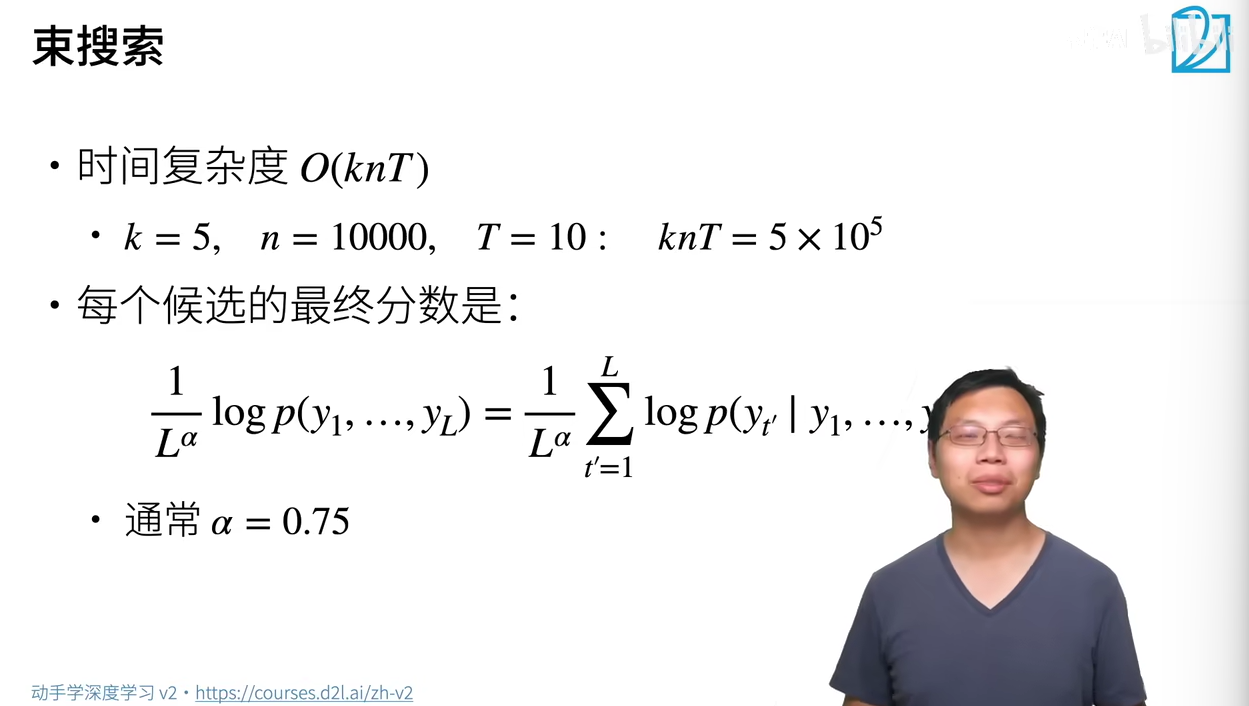



In [5]:
import torch 
import torch.nn as nn

class Seq2SeqEncoder(nn.Module):
    def __init__(self,vocab_size,embed_size,hidden_size,num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.rnn = nn.GRU(embed_size, hidden_size, num_layers = num_layers,batch_first = True)

    def forward(self,X):
        embs = self.embedding(X)
        outputs,state = self.rnn(embs)

        return outputs,state   

In [6]:
class Seq2SeqDecoder(nn.Module):
    def __init__(self,vocab_size,embed_size,hidden_size,num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,embed_size)
        self.dense = nn.Linear(hidden_size, vocab_size)
        self.rnn =nn.RNN(embed_size = embed_size,hidden_size = hidden_size,num_layers = num_layers)

    def forward (self,X,state):
        embs =self.embedding(X)
        out_puts,state =self.rnn(embs,state)
        outputs = self.dense(out_puts)
        return out_puts,state

In [7]:
class EncoderDecoder(nn.Module):
    def __init__(self,encoder,decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self,enc_X,dec_X):
        # 1. 编码器吃进源语言（比如英文句子 enc_X），产出最后的记忆状态 enc_state
        enc_outputs,enc_state = self.encoder(enc_X)

        # 2. 解码器吃进目标语言（比如中文句子 dec_X）和编码器的记忆状态 enc_state，产出解码器的输出 dec_outputs
        dec_outputs,dec_state = self.decoder(dec_X,enc_state)          

        return dec_outputs

In [8]:
def sequence_mask(X, valid_len, value=0):
    """在序列中屏蔽不相关的项（把超过 valid_len 的位置填为 0）"""
    maxlen = X.size(1) # 获取句子的最大长度（比如 5）
    
    # 构造一个 0 到 maxlen-1 的下标: [0, 1, 2, 3, 4]
    # 利用广播机制比较：下标 < valid_len 的位置为 True，否则为 False
    mask = torch.arange((maxlen), dtype=torch.float32,
                        device=X.device)[None, :] < valid_len[:, None]
    
    # 将 False 的位置全部填上 0（或者填其他值）
    X[~mask] = value
    return X

# 我们来做一个小测试：
test_X = torch.tensor([[1.0, 2.0, 3.0], 
                       [4.0, 5.0, 6.0]])
test_valid_len = torch.tensor([1, 2]) # 第1行只要前1个，第2行只要前2个

print("测试 Mask 后的结果：")
print(sequence_mask(test_X, test_valid_len))

测试 Mask 后的结果：
tensor([[1., 0., 0.],
        [4., 5., 0.]])


In [9]:
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """带遮罩的交叉熵损失函数"""
    def forward(self, pred, label, valid_len):
        # 1. 创建全 1 的权重矩阵，形状和 label 一样 [batch_size, num_steps]
        weights = torch.ones_like(label)
        # 2. 把超出有效长度的位置全部填 0
        weights = sequence_mask(weights, valid_len)
        
        # 3. 计算每个词未加权的原始交叉熵损失（不取平均，保留每个位置的 loss）
        self.reduction = 'none'
        # PyTorch 的 CrossEntropyLoss 期望预测值的维度是 [batch, vocab_size, seq_len]
        # 所以我们用 permute 调换一下维度
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        
        # 4. 重点来了：乘上 mask 权重，超过 valid_len 的 loss 直接变成 0！
        # 然后在句子时间轴 (dim=1) 上求平均
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        
        return weighted_loss

In [ ]:
# 1. 设定超参数
vocab_size = 1000   # 词汇表大小
embed_size = 32     # 词向量维度
num_hiddens = 64    # 隐藏层神经元数
num_layers = 2      # 2层深层 GRU

# 2. 实例化整个机器翻译大模型
encoder = Seq2SeqEncoder(vocab_size, embed_size, num_hiddens, num_layers)
class Seq2SeqDecoder(nn.Module):
    def __init__(self,vocab_size,embed_size,hidden_size,num_layers):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size,embed_size)
        self.dense = nn.Linear(hidden_size, vocab_size)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers=num_layers)

    def forward (self,X,state):
        embs = self.embedding(X)
        outputs, state = self.rnn(embs, state)
        outputs = self.dense(outputs)
        return outputs, state
model = EncoderDecoder(encoder, decoder)

# 3. 构造伪数据（模拟一个 Batch 包含 2 句话，每句话固定长 5 个词）
batch_size, num_steps = 2, 5
enc_X = torch.randint(0, vocab_size, (batch_size, num_steps)) # 英文输入
dec_X = torch.randint(0, vocab_size, (batch_size, num_steps)) # 中文输入 (带有 <bos>)
target_Y = torch.randint(0, vocab_size, (batch_size, num_steps)) # 真实的中文翻译标签 (带有 <eos>)
valid_len = torch.tensor([3, 5]) # 第1句话有效长度是3，第2句是5

# 4. 模型前向预测
pred = model(enc_X, dec_X)

# 5. 计算损失
loss_fn = MaskedSoftmaxCELoss()
loss = loss_fn(pred, target_Y, valid_len)

print("=== Seq2Seq 全流程测试成功 ===")
print("解码器预测输出形状 (pred shape):", pred.shape) # 应为 [2, 5, 1000]
print("每句话过滤 <pad> 后的真实损失 Loss:", loss)

TypeError: RNNBase.__init__() got an unexpected keyword argument 'embed_size'